In [1]:
# SoftSNN_Lite_Bound_and_Protect_MNIST.ipynb

# 1. Project Setup
# 2. Global Configuration
# 3. Load MNIST Dataset
# 4. Define Baseline SNN Model
# 5. Define Forward Pass
# 6. Train Baseline SNN
# 7. Evaluate Baseline SNN
# 8. Save Clean Model and Clean Weight Statistics
# 9. Baseline Summary

In [28]:
!pip install snntorch

In [29]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import snntorch as snn
from snntorch import surrogate
import matplotlib.pyplot as plt
import numpy as np

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [31]:
batch_size = 128
num_epochs = 3
num_steps = 25
learning_rate = 1e-3

num_inputs = 28 * 28
num_hidden = 128
num_outputs = 10

beta = 0.9

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [32]:
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Verify one batch
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])


In [33]:
class BaselineSNN(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs, beta, num_steps):
        super().__init__()

        spike_grad = surrogate.fast_sigmoid(slope=25)

        self.num_steps = num_steps

        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        # Flatten MNIST images from [batch, 1, 28, 28] to [batch, 784]
        x = x.view(x.size(0), -1)

        # Initialize membrane potentials
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        mem2_rec = []

        for step in range(self.num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec), torch.stack(mem2_rec)

In [34]:
net = BaselineSNN(
    num_inputs=num_inputs,
    num_hidden=num_hidden,
    num_outputs=num_outputs,
    beta=beta,
    num_steps=num_steps
).to(device)

print(net)

BaselineSNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (lif2): Leaky()
)


In [35]:
images, labels = next(iter(train_loader))
images = images.to(device)

spk_rec, mem_rec = net(images)

print("Spike record shape:", spk_rec.shape)
print("Membrane record shape:", mem_rec.shape)

Spike record shape: torch.Size([25, 128, 10])
Membrane record shape: torch.Size([25, 128, 10])


In [36]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

In [37]:
def train_baseline(net, train_loader, num_epochs):
    net.train()

    loss_history = []

    for epoch in range(num_epochs):
        running_loss = 0.0

        for batch_idx, (data, targets) in enumerate(train_loader):
            data = data.to(device)
            targets = targets.to(device)

            # Forward pass
            spk_rec, mem_rec = net(data)

            # Sum output spikes over time
            spk_count = spk_rec.sum(dim=0)

            # Classification loss
            loss = loss_fn(spk_count, targets)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    return loss_history

In [38]:
loss_history = train_baseline(net, train_loader, num_epochs)

Epoch 1/3, Loss: 0.7581
Epoch 2/3, Loss: 0.3976
Epoch 3/3, Loss: 0.2080


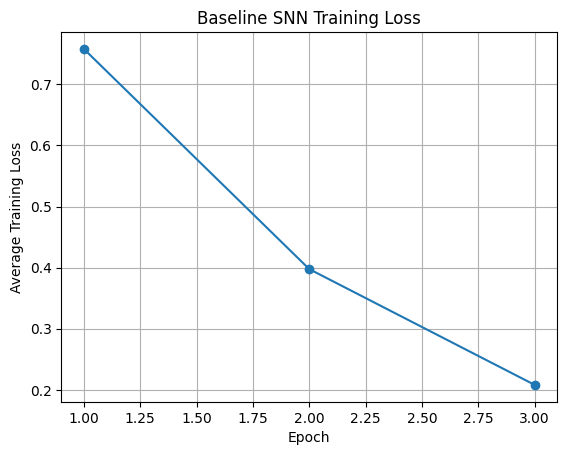

In [39]:
plt.figure()
plt.plot(range(1, num_epochs + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Baseline SNN Training Loss")
plt.grid(True)
plt.show()

In [40]:
def evaluate_accuracy(net, data_loader):
    net.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device)
            targets = targets.to(device)

            spk_rec, mem_rec = net(data)

            # Sum spikes over time
            spk_count = spk_rec.sum(dim=0)

            # Predicted class is the output neuron with the most spikes
            _, predicted = spk_count.max(dim=1)

            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [60]:
def evaluate_accuracy_and_output_spikes(net, data_loader):
    """
    Evaluates classification accuracy and average output spike count.

    Returns:
        accuracy: test accuracy in percent
        avg_output_spikes_per_sample: average total output spikes per input image
    """

    net.eval()

    correct = 0
    total = 0
    total_output_spikes = 0.0

    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device)
            targets = targets.to(device)

            spk_rec, mem_rec = net(data)

            # spk_rec shape: [num_steps, batch_size, num_outputs]
            spk_count = spk_rec.sum(dim=0)

            # Prediction = output neuron with the most spikes
            _, predicted = spk_count.max(dim=1)

            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            # Count all output spikes across all classes and all samples
            total_output_spikes += spk_count.sum().item()

    accuracy = 100 * correct / total
    avg_output_spikes_per_sample = total_output_spikes / total

    return accuracy, avg_output_spikes_per_sample

In [61]:
clean_model = load_clean_model()

clean_acc_check, clean_avg_spikes = evaluate_accuracy_and_output_spikes(
    clean_model,
    test_loader
)

print(f"Clean accuracy: {clean_acc_check:.2f}%")
print(f"Clean average output spikes/sample: {clean_avg_spikes:.2f}")

Clean accuracy: 94.21%
Clean average output spikes/sample: 13.95


In [62]:
fault_rates = [0.0, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
fault_multiplier = 2.0
seed = 42

spike_results = []

for fault_rate in fault_rates:
    # Clean model
    clean_model = load_clean_model()
    clean_acc, clean_spikes = evaluate_accuracy_and_output_spikes(
        clean_model,
        test_loader
    )

    # Faulted model
    faulted_model = load_clean_model()

    num_faults, total_weights = inject_positive_weight_faults(
        model=faulted_model,
        fault_rate=fault_rate,
        w_max=w_max,
        fault_multiplier=fault_multiplier,
        seed=seed
    )

    faulted_acc, faulted_spikes = evaluate_accuracy_and_output_spikes(
        faulted_model,
        test_loader
    )

    # BnP1 model
    bnp1_model = load_clean_model()

    inject_positive_weight_faults(
        model=bnp1_model,
        fault_rate=fault_rate,
        w_max=w_max,
        fault_multiplier=fault_multiplier,
        seed=seed
    )

    apply_bnp_weight_bounding(
        model=bnp1_model,
        w_max=w_max,
        method="bnp1"
    )

    bnp1_acc, bnp1_spikes = evaluate_accuracy_and_output_spikes(
        bnp1_model,
        test_loader
    )

    # BnP2 model
    bnp2_model = load_clean_model()

    inject_positive_weight_faults(
        model=bnp2_model,
        fault_rate=fault_rate,
        w_max=w_max,
        fault_multiplier=fault_multiplier,
        seed=seed
    )

    apply_bnp_weight_bounding(
        model=bnp2_model,
        w_max=w_max,
        method="bnp2"
    )

    bnp2_acc, bnp2_spikes = evaluate_accuracy_and_output_spikes(
        bnp2_model,
        test_loader
    )

    spike_results.append({
        "fault_rate": fault_rate,
        "num_faults": num_faults,
        "total_weights": total_weights,
        "clean_accuracy": clean_acc,
        "faulted_accuracy": faulted_acc,
        "bnp1_accuracy": bnp1_acc,
        "bnp2_accuracy": bnp2_acc,
        "clean_avg_output_spikes": clean_spikes,
        "faulted_avg_output_spikes": faulted_spikes,
        "bnp1_avg_output_spikes": bnp1_spikes,
        "bnp2_avg_output_spikes": bnp2_spikes
    })

    print(
        f"Fault rate: {fault_rate:.4f} | "
        f"Faulted spikes: {faulted_spikes:.2f} | "
        f"BnP1 spikes: {bnp1_spikes:.2f} | "
        f"BnP2 spikes: {bnp2_spikes:.2f}"
    )

Fault rate: 0.0000 | Faulted spikes: 13.95 | BnP1 spikes: 13.95 | BnP2 spikes: 13.95
Fault rate: 0.0001 | Faulted spikes: 14.01 | BnP1 spikes: 13.95 | BnP2 spikes: 13.99
Fault rate: 0.0005 | Faulted spikes: 13.99 | BnP1 spikes: 13.95 | BnP2 spikes: 13.97
Fault rate: 0.0010 | Faulted spikes: 14.03 | BnP1 spikes: 13.96 | BnP2 spikes: 14.00
Fault rate: 0.0020 | Faulted spikes: 36.40 | BnP1 spikes: 14.02 | BnP2 spikes: 25.97
Fault rate: 0.0050 | Faulted spikes: 35.72 | BnP1 spikes: 14.00 | BnP2 spikes: 25.98
Fault rate: 0.0100 | Faulted spikes: 50.89 | BnP1 spikes: 13.39 | BnP2 spikes: 31.30
Fault rate: 0.0200 | Faulted spikes: 79.36 | BnP1 spikes: 13.69 | BnP2 spikes: 46.08
Fault rate: 0.0500 | Faulted spikes: 161.79 | BnP1 spikes: 14.42 | BnP2 spikes: 100.81
Fault rate: 0.1000 | Faulted spikes: 190.34 | BnP1 spikes: 14.39 | BnP2 spikes: 168.72


In [63]:
spike_df = pd.DataFrame(spike_results)
spike_df

,fault_rate,num_faults,total_weights,clean_accuracy,faulted_accuracy,bnp1_accuracy,bnp2_accuracy,clean_avg_output_spikes,faulted_avg_output_spikes,bnp1_avg_output_spikes,bnp2_avg_output_spikes
0,0.0000,0,101632,94.21,94.21,94.21,94.21,13.946,13.9460,13.9460,13.9460
1,0.0001,10,101632,94.21,94.07,94.20,94.17,13.946,14.0120,13.9466,13.9866
2,0.0005,50,101632,94.21,93.95,94.24,94.19,13.946,13.9923,13.9502,13.9692
3,0.0010,97,101632,94.21,93.72,94.31,94.12,13.946,14.0307,13.9571,14.0035
4,0.0020,201,101632,94.21,11.39,94.24,41.91,13.946,36.3954,14.0169,25.9717
5,0.0050,515,101632,94.21,12.49,94.27,38.56,13.946,35.7198,14.0043,25.9822
6,0.0100,1026,101632,94.21,12.33,93.14,40.49,13.946,50.8882,13.3924,31.3019
7,0.0200,1992,101632,94.21,18.24,93.06,25.67,13.946,79.3627,13.6878,46.0789
8,0.0500,4959,101632,94.21,11.79,90.32,20.39,13.946,161.7917,14.4219,100.8062
9,0.1000,10098,101632,94.21,16.18,90.54,18.78,13.946,190.3440,14.3861,168.7173


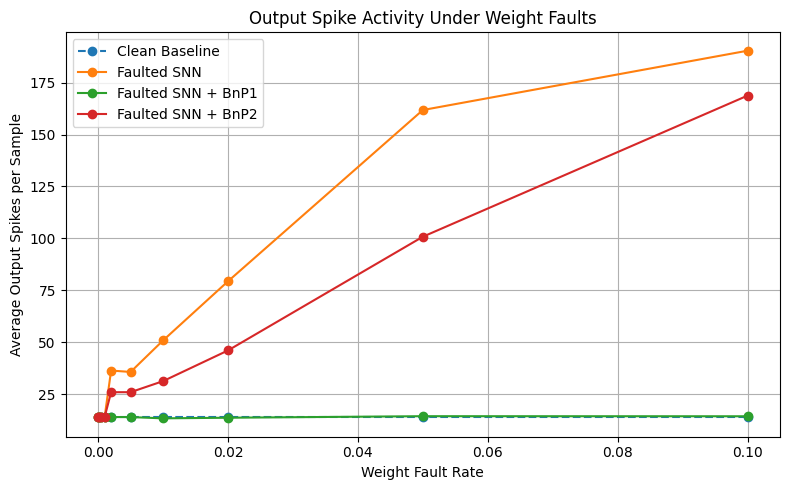

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    spike_df["fault_rate"],
    spike_df["clean_avg_output_spikes"],
    marker="o",
    linestyle="--",
    label="Clean Baseline"
)

plt.plot(
    spike_df["fault_rate"],
    spike_df["faulted_avg_output_spikes"],
    marker="o",
    label="Faulted SNN"
)

plt.plot(
    spike_df["fault_rate"],
    spike_df["bnp1_avg_output_spikes"],
    marker="o",
    label="Faulted SNN + BnP1"
)

plt.plot(
    spike_df["fault_rate"],
    spike_df["bnp2_avg_output_spikes"],
    marker="o",
    label="Faulted SNN + BnP2"
)

plt.xlabel("Weight Fault Rate")
plt.ylabel("Average Output Spikes per Sample")
plt.title("Output Spike Activity Under Weight Faults")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

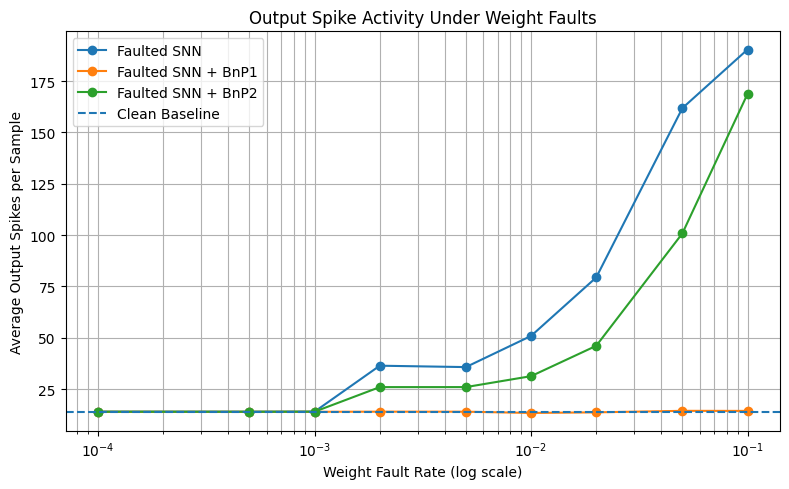

In [65]:
nonzero_spike_df = spike_df[spike_df["fault_rate"] > 0]

plt.figure(figsize=(8, 5))

plt.semilogx(
    nonzero_spike_df["fault_rate"],
    nonzero_spike_df["faulted_avg_output_spikes"],
    marker="o",
    label="Faulted SNN"
)

plt.semilogx(
    nonzero_spike_df["fault_rate"],
    nonzero_spike_df["bnp1_avg_output_spikes"],
    marker="o",
    label="Faulted SNN + BnP1"
)

plt.semilogx(
    nonzero_spike_df["fault_rate"],
    nonzero_spike_df["bnp2_avg_output_spikes"],
    marker="o",
    label="Faulted SNN + BnP2"
)

plt.axhline(
    clean_avg_spikes,
    linestyle="--",
    label="Clean Baseline"
)

plt.xlabel("Weight Fault Rate (log scale)")
plt.ylabel("Average Output Spikes per Sample")
plt.title("Output Spike Activity Under Weight Faults")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
clean_accuracy = evaluate_accuracy(net, test_loader)
print(f"Clean baseline test accuracy: {clean_accuracy:.2f}%")

Clean baseline test accuracy: 94.21%


In [42]:
torch.save(net.state_dict(), "baseline_snn_mnist.pth")
print("Saved clean baseline model as baseline_snn_mnist.pth")

Saved clean baseline model as baseline_snn_mnist.pth


In [43]:
def get_weight_statistics(net):
    all_weights = []

    for name, param in net.named_parameters():
        if "weight" in name:
            all_weights.append(param.detach().cpu().flatten())

    all_weights = torch.cat(all_weights)

    stats = {
        "w_max": all_weights.max().item(),
        "w_min": all_weights.min().item(),
        "w_mean": all_weights.mean().item(),
        "w_std": all_weights.std().item()
    }

    return stats

clean_weight_stats = get_weight_statistics(net)

for key, value in clean_weight_stats.items():
    print(f"{key}: {value:.6f}")

w_max: 0.304770
w_min: -0.215144
w_mean: 0.000646
w_std: 0.030118


In [44]:
w_max = clean_weight_stats["w_max"]
print(f"Clean weight threshold for BnP: {w_max:.6f}")

Clean weight threshold for BnP: 0.304770


In [45]:
baseline_summary = {
    "Dataset": "MNIST",
    "Model": "Fully connected LIF SNN",
    "Input size": num_inputs,
    "Hidden neurons": num_hidden,
    "Output classes": num_outputs,
    "Time steps": num_steps,
    "Beta": beta,
    "Epochs": num_epochs,
    "Clean test accuracy (%)": clean_accuracy,
    "Clean max weight w_max": clean_weight_stats["w_max"],
    "Clean min weight w_min": clean_weight_stats["w_min"],
    "Clean mean weight": clean_weight_stats["w_mean"],
    "Clean weight std": clean_weight_stats["w_std"]
}

baseline_summary

{'Dataset': 'MNIST',
 'Model': 'Fully connected LIF SNN',
 'Input size': 784,
 'Hidden neurons': 128,
 'Output classes': 10,
 'Time steps': 25,
 'Beta': 0.9,
 'Epochs': 3,
 'Clean test accuracy (%)': 94.21,
 'Clean max weight w_max': 0.3047701120376587,
 'Clean min weight w_min': -0.21514439582824707,
 'Clean mean weight': 0.0006460291333496571,
 'Clean weight std': 0.030117807909846306}

## Baseline Result

The clean baseline SNN achieved 94.21% test accuracy on MNIST after 3 training epochs. The maximum trained weight was w_{max}=0.304770, which will be used as the Bound-and-Protect threshold during the fault-injection experiments.

In [46]:
import os

model_path = "baseline_snn_mnist.pth"

print("Model file exists:", os.path.exists(model_path))

Model file exists: True


In [47]:
def load_clean_model(model_path="baseline_snn_mnist.pth"):
    clean_model = BaselineSNN(
        num_inputs=num_inputs,
        num_hidden=num_hidden,
        num_outputs=num_outputs,
        beta=beta,
        num_steps=num_steps
    ).to(device)

    clean_model.load_state_dict(torch.load(model_path, map_location=device))
    clean_model.eval()

    return clean_model

In [48]:
clean_model = load_clean_model()

clean_accuracy_check = evaluate_accuracy(clean_model, test_loader)
print(f"Reloaded clean model accuracy: {clean_accuracy_check:.2f}%")

Reloaded clean model accuracy: 94.21%


10. Fault Mode: Weight Corruption

In [49]:
def inject_positive_weight_faults(model, fault_rate, w_max, fault_multiplier=4.0, seed=42):
    """
    Injects hardware-inspired weight corruption into a model.

    Selected weights are replaced with positive outlier values greater than w_max.
    This models the dangerous SoftSNN case where corrupted weights become too large.

    Args:
        model: SNN model to corrupt
        fault_rate: fraction of weights to corrupt
        w_max: maximum clean trained weight
        fault_multiplier: corrupted weights become w_max * fault_multiplier
        seed: random seed for reproducibility

    Returns:
        total_faults: number of corrupted weights
        total_weights: total number of eligible weights
    """

    torch.manual_seed(seed)

    total_faults = 0
    total_weights = 0

    with torch.no_grad():
        for name, param in model.named_parameters():
            if "weight" in name:
                mask = torch.rand_like(param) < fault_rate

                num_faults = mask.sum().item()
                total_faults += num_faults
                total_weights += param.numel()

                param[mask] = w_max * fault_multiplier

    return total_faults, total_weights

In [50]:
fault_rate = 0.01

faulted_model = load_clean_model()

num_faults, total_weights = inject_positive_weight_faults(
    model=faulted_model,
    fault_rate=fault_rate,
    w_max=w_max,
    fault_multiplier=4.0,
    seed=42
)

faulted_accuracy = evaluate_accuracy(faulted_model, test_loader)

print(f"Fault rate: {fault_rate}")
print(f"Corrupted weights: {num_faults} / {total_weights}")
print(f"Faulted model accuracy: {faulted_accuracy:.2f}%")

Fault rate: 0.01
Corrupted weights: 1026 / 101632
Faulted model accuracy: 18.06%


In [51]:
fault_rates = [0.0, 0.001, 0.005, 0.01, 0.05, 0.1]

fault_results = []

for fault_rate in fault_rates:
    faulted_model = load_clean_model()

    num_faults, total_weights = inject_positive_weight_faults(
        model=faulted_model,
        fault_rate=fault_rate,
        w_max=w_max,
        fault_multiplier=2.0,
        seed=42
    )

    acc = evaluate_accuracy(faulted_model, test_loader)

    fault_results.append({
        "fault_rate": fault_rate,
        "num_faults": num_faults,
        "total_weights": total_weights,
        "accuracy": acc
    })

    print(f"Fault rate: {fault_rate:.3f} | Faults: {num_faults}/{total_weights} | Accuracy: {acc:.2f}%")

Fault rate: 0.000 | Faults: 0/101632 | Accuracy: 94.21%
Fault rate: 0.001 | Faults: 97/101632 | Accuracy: 93.72%
Fault rate: 0.005 | Faults: 515/101632 | Accuracy: 12.49%
Fault rate: 0.010 | Faults: 1026/101632 | Accuracy: 12.33%
Fault rate: 0.050 | Faults: 4959/101632 | Accuracy: 11.79%
Fault rate: 0.100 | Faults: 10098/101632 | Accuracy: 16.18%


In [52]:
import pandas as pd

fault_df = pd.DataFrame(fault_results)
fault_df

,fault_rate,num_faults,total_weights,accuracy
0,0.000,0,101632,94.21
1,0.001,97,101632,93.72
2,0.005,515,101632,12.49
3,0.010,1026,101632,12.33
4,0.050,4959,101632,11.79
5,0.100,10098,101632,16.18


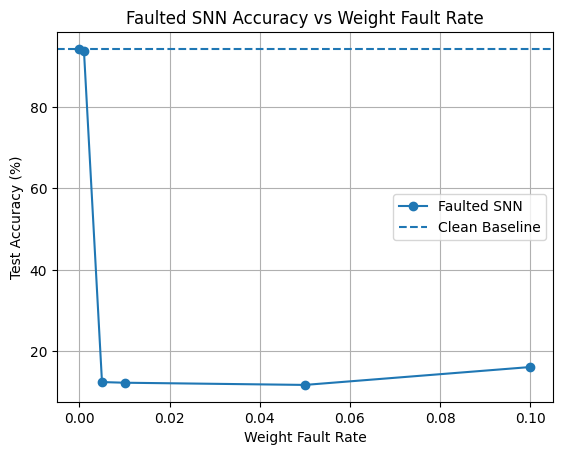

In [53]:
plt.figure()
plt.plot(fault_df["fault_rate"], fault_df["accuracy"], marker="o", label="Faulted SNN")
plt.axhline(clean_accuracy, linestyle="--", label="Clean Baseline")

plt.xlabel("Weight Fault Rate")
plt.ylabel("Test Accuracy (%)")
plt.title("Faulted SNN Accuracy vs Weight Fault Rate")
plt.grid(True)
plt.legend()
plt.show()

11. Protected Mode: BnP1 and BnP2

In [54]:
def apply_bnp_weight_bounding(model, w_max, method="bnp1"):
    """
    Applies Bound-and-Protect weight bounding.

    BnP1: weights greater than w_max are replaced with 0.
    BnP2: weights greater than w_max are replaced with w_max.

    Args:
        model: faulted SNN model
        w_max: maximum clean trained weight
        method: "bnp1" or "bnp2"

    Returns:
        total_bounded: number of weights corrected
    """

    total_bounded = 0

    with torch.no_grad():
        for name, param in model.named_parameters():
            if "weight" in name:
                mask = param > w_max
                total_bounded += mask.sum().item()

                if method.lower() == "bnp1":
                    param[mask] = 0.0

                elif method.lower() == "bnp2":
                    param[mask] = w_max

                else:
                    raise ValueError("method must be 'bnp1' or 'bnp2'")

    return total_bounded

In [55]:
fault_rate = 0.005
fault_multiplier = 2.0
seed = 42

# Unprotected faulted model
faulted_model = load_clean_model()

num_faults, total_weights = inject_positive_weight_faults(
    model=faulted_model,
    fault_rate=fault_rate,
    w_max=w_max,
    fault_multiplier=fault_multiplier,
    seed=seed
)

faulted_acc = evaluate_accuracy(faulted_model, test_loader)

# BnP1 protected model
bnp1_model = load_clean_model()

num_faults_bnp1, _ = inject_positive_weight_faults(
    model=bnp1_model,
    fault_rate=fault_rate,
    w_max=w_max,
    fault_multiplier=fault_multiplier,
    seed=seed
)

num_bounded_bnp1 = apply_bnp_weight_bounding(
    model=bnp1_model,
    w_max=w_max,
    method="bnp1"
)

bnp1_acc = evaluate_accuracy(bnp1_model, test_loader)

# BnP2 protected model
bnp2_model = load_clean_model()

num_faults_bnp2, _ = inject_positive_weight_faults(
    model=bnp2_model,
    fault_rate=fault_rate,
    w_max=w_max,
    fault_multiplier=fault_multiplier,
    seed=seed
)

num_bounded_bnp2 = apply_bnp_weight_bounding(
    model=bnp2_model,
    w_max=w_max,
    method="bnp2"
)

bnp2_acc = evaluate_accuracy(bnp2_model, test_loader)

print(f"Fault rate: {fault_rate}")
print(f"Injected faults: {num_faults} / {total_weights}")
print(f"Unprotected faulted accuracy: {faulted_acc:.2f}%")
print(f"BnP1 bounded weights: {num_bounded_bnp1}, accuracy: {bnp1_acc:.2f}%")
print(f"BnP2 bounded weights: {num_bounded_bnp2}, accuracy: {bnp2_acc:.2f}%")

Fault rate: 0.005
Injected faults: 515 / 101632
Unprotected faulted accuracy: 12.49%
BnP1 bounded weights: 515, accuracy: 94.27%
BnP2 bounded weights: 515, accuracy: 38.56%


# 12. Fault-Rate Sweep with BnP1 and BnP2

In [56]:
fault_rates = [0.0, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
fault_multiplier = 2.0
seed = 42

comparison_results = []

for fault_rate in fault_rates:
    # Unprotected faulted model
    faulted_model = load_clean_model()

    num_faults, total_weights = inject_positive_weight_faults(
        model=faulted_model,
        fault_rate=fault_rate,
        w_max=w_max,
        fault_multiplier=fault_multiplier,
        seed=seed
    )

    faulted_acc = evaluate_accuracy(faulted_model, test_loader)

    # BnP1 model
    bnp1_model = load_clean_model()

    inject_positive_weight_faults(
        model=bnp1_model,
        fault_rate=fault_rate,
        w_max=w_max,
        fault_multiplier=fault_multiplier,
        seed=seed
    )

    num_bounded_bnp1 = apply_bnp_weight_bounding(
        model=bnp1_model,
        w_max=w_max,
        method="bnp1"
    )

    bnp1_acc = evaluate_accuracy(bnp1_model, test_loader)

    # BnP2 model
    bnp2_model = load_clean_model()

    inject_positive_weight_faults(
        model=bnp2_model,
        fault_rate=fault_rate,
        w_max=w_max,
        fault_multiplier=fault_multiplier,
        seed=seed
    )

    num_bounded_bnp2 = apply_bnp_weight_bounding(
        model=bnp2_model,
        w_max=w_max,
        method="bnp2"
    )

    bnp2_acc = evaluate_accuracy(bnp2_model, test_loader)

    comparison_results.append({
        "fault_rate": fault_rate,
        "num_faults": num_faults,
        "total_weights": total_weights,
        "faulted_accuracy": faulted_acc,
        "bnp1_accuracy": bnp1_acc,
        "bnp2_accuracy": bnp2_acc,
        "bnp1_bounded_weights": num_bounded_bnp1,
        "bnp2_bounded_weights": num_bounded_bnp2
    })

    print(
        f"Fault rate: {fault_rate:.4f} | "
        f"Faults: {num_faults}/{total_weights} | "
        f"Faulted: {faulted_acc:.2f}% | "
        f"BnP1: {bnp1_acc:.2f}% | "
        f"BnP2: {bnp2_acc:.2f}%"
    )

Fault rate: 0.0000 | Faults: 0/101632 | Faulted: 94.21% | BnP1: 94.21% | BnP2: 94.21%
Fault rate: 0.0001 | Faults: 10/101632 | Faulted: 94.07% | BnP1: 94.20% | BnP2: 94.17%
Fault rate: 0.0005 | Faults: 50/101632 | Faulted: 93.95% | BnP1: 94.24% | BnP2: 94.19%
Fault rate: 0.0010 | Faults: 97/101632 | Faulted: 93.72% | BnP1: 94.31% | BnP2: 94.12%
Fault rate: 0.0020 | Faults: 201/101632 | Faulted: 11.39% | BnP1: 94.24% | BnP2: 41.91%
Fault rate: 0.0050 | Faults: 515/101632 | Faulted: 12.49% | BnP1: 94.27% | BnP2: 38.56%
Fault rate: 0.0100 | Faults: 1026/101632 | Faulted: 12.33% | BnP1: 93.14% | BnP2: 40.49%
Fault rate: 0.0200 | Faults: 1992/101632 | Faulted: 18.24% | BnP1: 93.06% | BnP2: 25.67%
Fault rate: 0.0500 | Faults: 4959/101632 | Faulted: 11.79% | BnP1: 90.32% | BnP2: 20.39%
Fault rate: 0.1000 | Faults: 10098/101632 | Faulted: 16.18% | BnP1: 90.54% | BnP2: 18.78%


In [57]:
comparison_df = pd.DataFrame(comparison_results)
comparison_df

,fault_rate,num_faults,total_weights,faulted_accuracy,bnp1_accuracy,bnp2_accuracy,bnp1_bounded_weights,bnp2_bounded_weights
0,0.0000,0,101632,94.21,94.21,94.21,0,0
1,0.0001,10,101632,94.07,94.20,94.17,10,10
2,0.0005,50,101632,93.95,94.24,94.19,50,50
3,0.0010,97,101632,93.72,94.31,94.12,97,97
4,0.0020,201,101632,11.39,94.24,41.91,201,201
5,0.0050,515,101632,12.49,94.27,38.56,515,515
6,0.0100,1026,101632,12.33,93.14,40.49,1026,1026
7,0.0200,1992,101632,18.24,93.06,25.67,1992,1992
8,0.0500,4959,101632,11.79,90.32,20.39,4959,4959
9,0.1000,10098,101632,16.18,90.54,18.78,10098,10098


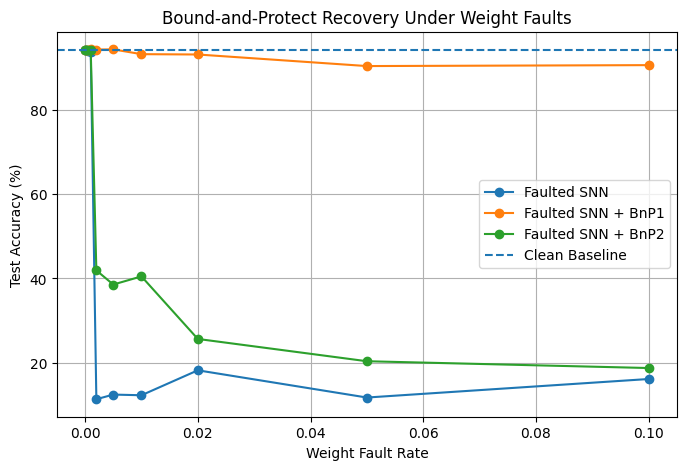

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["fault_rate"],
    comparison_df["faulted_accuracy"],
    marker="o",
    label="Faulted SNN"
)

plt.plot(
    comparison_df["fault_rate"],
    comparison_df["bnp1_accuracy"],
    marker="o",
    label="Faulted SNN + BnP1"
)

plt.plot(
    comparison_df["fault_rate"],
    comparison_df["bnp2_accuracy"],
    marker="o",
    label="Faulted SNN + BnP2"
)

plt.axhline(
    clean_accuracy,
    linestyle="--",
    label="Clean Baseline"
)

plt.xlabel("Weight Fault Rate")
plt.ylabel("Test Accuracy (%)")
plt.title("Bound-and-Protect Recovery Under Weight Faults")
plt.grid(True)
plt.legend()
plt.show()

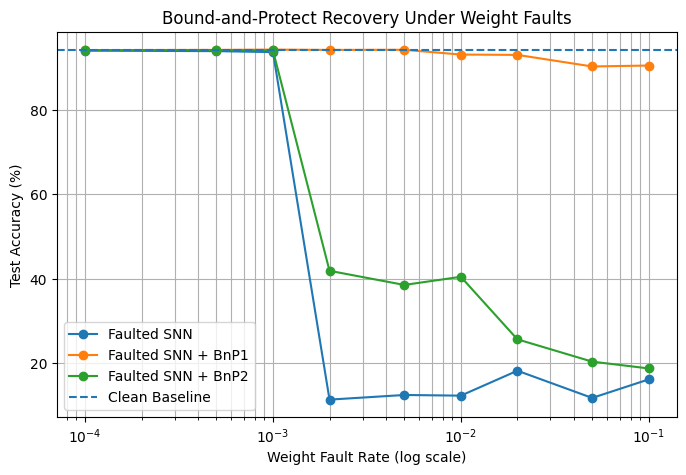

In [59]:
nonzero_df = comparison_df[comparison_df["fault_rate"] > 0]

plt.figure(figsize=(8, 5))

plt.semilogx(
    nonzero_df["fault_rate"],
    nonzero_df["faulted_accuracy"],
    marker="o",
    label="Faulted SNN"
)

plt.semilogx(
    nonzero_df["fault_rate"],
    nonzero_df["bnp1_accuracy"],
    marker="o",
    label="Faulted SNN + BnP1"
)

plt.semilogx(
    nonzero_df["fault_rate"],
    nonzero_df["bnp2_accuracy"],
    marker="o",
    label="Faulted SNN + BnP2"
)

plt.axhline(
    clean_accuracy,
    linestyle="--",
    label="Clean Baseline"
)

plt.xlabel("Weight Fault Rate (log scale)")
plt.ylabel("Test Accuracy (%)")
plt.title("Bound-and-Protect Recovery Under Weight Faults")
plt.grid(True, which="both")
plt.legend()
plt.show()

13. Multi-Seed Fault Map Averaging

In [67]:
seeds = [0, 1, 2, 3, 4]
fault_rates = [0.0, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
fault_multiplier = 2.0

multi_seed_results = []

for seed_value in seeds:
    for fault_rate in fault_rates:

        # Faulted model
        faulted_model = load_clean_model()

        num_faults, total_weights = inject_positive_weight_faults(
            model=faulted_model,
            fault_rate=fault_rate,
            w_max=w_max,
            fault_multiplier=fault_multiplier,
            seed=seed_value
        )

        faulted_acc, faulted_spikes = evaluate_accuracy_and_output_spikes(
            faulted_model,
            test_loader
        )

        # BnP1 model
        bnp1_model = load_clean_model()

        inject_positive_weight_faults(
            model=bnp1_model,
            fault_rate=fault_rate,
            w_max=w_max,
            fault_multiplier=fault_multiplier,
            seed=seed_value
        )

        apply_bnp_weight_bounding(
            model=bnp1_model,
            w_max=w_max,
            method="bnp1"
        )

        bnp1_acc, bnp1_spikes = evaluate_accuracy_and_output_spikes(
            bnp1_model,
            test_loader
        )

        # BnP2 model
        bnp2_model = load_clean_model()

        inject_positive_weight_faults(
            model=bnp2_model,
            fault_rate=fault_rate,
            w_max=w_max,
            fault_multiplier=fault_multiplier,
            seed=seed_value
        )

        apply_bnp_weight_bounding(
            model=bnp2_model,
            w_max=w_max,
            method="bnp2"
        )

        bnp2_acc, bnp2_spikes = evaluate_accuracy_and_output_spikes(
            bnp2_model,
            test_loader
        )

        multi_seed_results.append({
            "seed": seed_value,
            "fault_rate": fault_rate,
            "num_faults": num_faults,
            "total_weights": total_weights,
            "faulted_accuracy": faulted_acc,
            "bnp1_accuracy": bnp1_acc,
            "bnp2_accuracy": bnp2_acc,
            "faulted_avg_output_spikes": faulted_spikes,
            "bnp1_avg_output_spikes": bnp1_spikes,
            "bnp2_avg_output_spikes": bnp2_spikes
        })

        print(
            f"Seed: {seed_value} | "
            f"Fault rate: {fault_rate:.4f} | "
            f"Faulted: {faulted_acc:.2f}% | "
            f"BnP1: {bnp1_acc:.2f}% | "
            f"BnP2: {bnp2_acc:.2f}%"
        )

Seed: 0 | Fault rate: 0.0000 | Faulted: 94.21% | BnP1: 94.21% | BnP2: 94.21%
Seed: 0 | Fault rate: 0.0001 | Faulted: 93.92% | BnP1: 94.18% | BnP2: 94.06%
Seed: 0 | Fault rate: 0.0005 | Faulted: 87.46% | BnP1: 94.13% | BnP2: 93.73%
Seed: 0 | Fault rate: 0.0010 | Faulted: 86.35% | BnP1: 94.15% | BnP2: 93.86%
Seed: 0 | Fault rate: 0.0020 | Faulted: 84.99% | BnP1: 94.23% | BnP2: 93.49%
Seed: 0 | Fault rate: 0.0050 | Faulted: 42.83% | BnP1: 94.07% | BnP2: 82.98%
Seed: 0 | Fault rate: 0.0100 | Faulted: 28.14% | BnP1: 93.36% | BnP2: 58.81%
Seed: 0 | Fault rate: 0.0200 | Faulted: 21.60% | BnP1: 91.88% | BnP2: 47.59%
Seed: 0 | Fault rate: 0.0500 | Faulted: 12.40% | BnP1: 90.76% | BnP2: 15.99%
Seed: 0 | Fault rate: 0.1000 | Faulted: 10.89% | BnP1: 82.42% | BnP2: 12.25%
Seed: 1 | Fault rate: 0.0000 | Faulted: 94.21% | BnP1: 94.21% | BnP2: 94.21%
Seed: 1 | Fault rate: 0.0001 | Faulted: 94.22% | BnP1: 94.20% | BnP2: 94.34%
Seed: 1 | Fault rate: 0.0005 | Faulted: 93.52% | BnP1: 94.18% | BnP2: 94.13%

In [68]:
multi_seed_df = pd.DataFrame(multi_seed_results)

summary_df = multi_seed_df.groupby("fault_rate").agg(
    faulted_accuracy_mean=("faulted_accuracy", "mean"),
    faulted_accuracy_std=("faulted_accuracy", "std"),
    bnp1_accuracy_mean=("bnp1_accuracy", "mean"),
    bnp1_accuracy_std=("bnp1_accuracy", "std"),
    bnp2_accuracy_mean=("bnp2_accuracy", "mean"),
    bnp2_accuracy_std=("bnp2_accuracy", "std"),

    faulted_spikes_mean=("faulted_avg_output_spikes", "mean"),
    faulted_spikes_std=("faulted_avg_output_spikes", "std"),
    bnp1_spikes_mean=("bnp1_avg_output_spikes", "mean"),
    bnp1_spikes_std=("bnp1_avg_output_spikes", "std"),
    bnp2_spikes_mean=("bnp2_avg_output_spikes", "mean"),
    bnp2_spikes_std=("bnp2_avg_output_spikes", "std")
).reset_index()

summary_df

,fault_rate,faulted_accuracy_mean,faulted_accuracy_std,bnp1_accuracy_mean,bnp1_accuracy_std,bnp2_accuracy_mean,bnp2_accuracy_std,faulted_spikes_mean,faulted_spikes_std,bnp1_spikes_mean,bnp1_spikes_std,bnp2_spikes_mean,bnp2_spikes_std
0,0.0000,94.210,0.000000,94.210,0.000000,94.210,0.000000,13.94600,0.000000,13.94600,0.000000,13.94600,0.000000
1,0.0001,94.008,0.144637,94.200,0.033912,94.166,0.105024,13.86544,0.074361,13.94552,0.003901,13.90846,0.044789
2,0.0005,92.334,2.731791,94.176,0.033615,94.040,0.178606,14.35252,0.973786,13.94438,0.006283,14.00760,0.250978
3,0.0010,88.056,7.151023,94.128,0.095760,93.492,0.919494,15.49850,2.055763,13.90144,0.070809,14.41762,0.668082
4,0.0020,81.806,17.093049,94.126,0.162573,92.502,2.492342,16.86434,4.761626,13.81882,0.229907,14.78804,1.678193
5,0.0050,53.500,19.380476,93.980,0.199499,84.624,7.480269,29.61230,11.472600,13.91308,0.437969,19.23018,4.651209
6,0.0100,32.578,12.805787,93.716,0.308350,65.714,21.829300,57.25866,19.998660,14.03458,0.425985,30.15052,9.481522
7,0.0200,21.200,4.313861,92.974,0.885652,44.830,9.958195,97.66762,24.946295,14.11274,0.848065,47.94508,13.142545
8,0.0500,12.984,3.099005,91.672,1.440094,19.084,4.971803,173.75046,21.802504,14.77408,1.259342,118.22094,24.867866
9,0.1000,13.310,1.709313,87.060,4.226577,14.896,2.490227,198.91392,6.976702,14.90374,0.961124,177.36922,8.872211


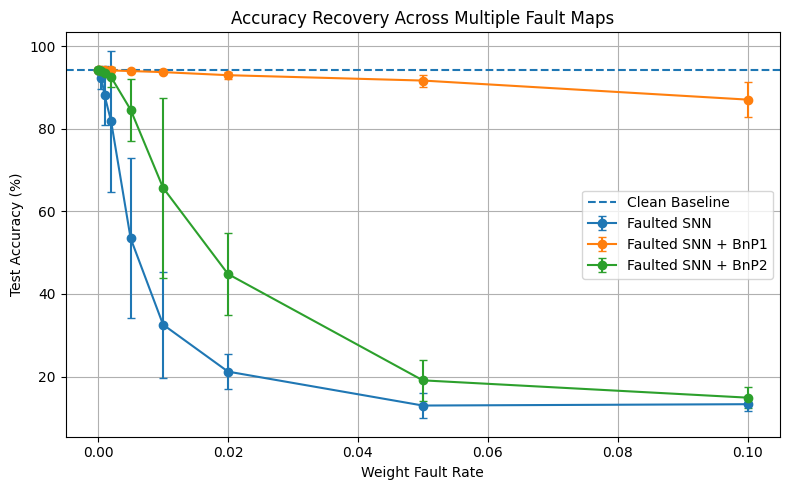

In [69]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_df["fault_rate"],
    summary_df["faulted_accuracy_mean"],
    yerr=summary_df["faulted_accuracy_std"],
    marker="o",
    capsize=3,
    label="Faulted SNN"
)

plt.errorbar(
    summary_df["fault_rate"],
    summary_df["bnp1_accuracy_mean"],
    yerr=summary_df["bnp1_accuracy_std"],
    marker="o",
    capsize=3,
    label="Faulted SNN + BnP1"
)

plt.errorbar(
    summary_df["fault_rate"],
    summary_df["bnp2_accuracy_mean"],
    yerr=summary_df["bnp2_accuracy_std"],
    marker="o",
    capsize=3,
    label="Faulted SNN + BnP2"
)

plt.axhline(clean_accuracy, linestyle="--", label="Clean Baseline")

plt.xlabel("Weight Fault Rate")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy Recovery Across Multiple Fault Maps")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

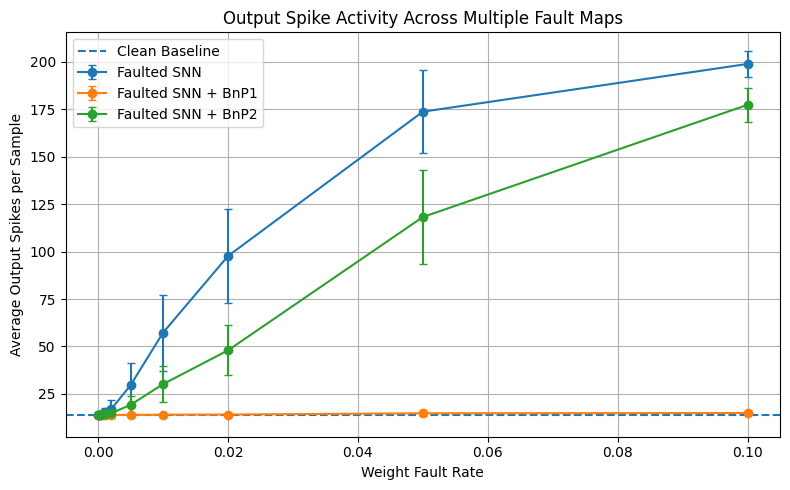

In [70]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    summary_df["fault_rate"],
    summary_df["faulted_spikes_mean"],
    yerr=summary_df["faulted_spikes_std"],
    marker="o",
    capsize=3,
    label="Faulted SNN"
)

plt.errorbar(
    summary_df["fault_rate"],
    summary_df["bnp1_spikes_mean"],
    yerr=summary_df["bnp1_spikes_std"],
    marker="o",
    capsize=3,
    label="Faulted SNN + BnP1"
)

plt.errorbar(
    summary_df["fault_rate"],
    summary_df["bnp2_spikes_mean"],
    yerr=summary_df["bnp2_spikes_std"],
    marker="o",
    capsize=3,
    label="Faulted SNN + BnP2"
)

plt.axhline(clean_avg_spikes, linestyle="--", label="Clean Baseline")

plt.xlabel("Weight Fault Rate")
plt.ylabel("Average Output Spikes per Sample")
plt.title("Output Spike Activity Across Multiple Fault Maps")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
multi_seed_df.to_csv("softsnn_lite_multi_seed_raw_results.csv", index=False)
summary_df.to_csv("softsnn_lite_multi_seed_summary_results.csv", index=False)

14. Hardware Logic Abstraction

In [72]:
def synapse_guard(weight, w_threshold, replacement_value):
    """
    Software abstraction of the synapse guard circuit.

    Hardware equivalent:
    - comparator: weight >= w_threshold
    - mux: selects replacement_value or original weight
    """

    if weight >= w_threshold:
        bounded_weight = replacement_value
        fault_detected = True
    else:
        bounded_weight = weight
        fault_detected = False

    return bounded_weight, fault_detected

In [73]:
test_weight = 2.0 * w_max

# BnP1: replacement = 0
bnp1_weight, bnp1_fault = synapse_guard(
    weight=test_weight,
    w_threshold=w_max,
    replacement_value=0.0
)

# BnP2: replacement = w_max
bnp2_weight, bnp2_fault = synapse_guard(
    weight=test_weight,
    w_threshold=w_max,
    replacement_value=w_max
)

print(f"Original corrupted weight: {test_weight:.6f}")
print(f"BnP1 output weight: {bnp1_weight:.6f}, fault detected: {bnp1_fault}")
print(f"BnP2 output weight: {bnp2_weight:.6f}, fault detected: {bnp2_fault}")

Original corrupted weight: 0.609540
BnP1 output weight: 0.000000, fault detected: True
BnP2 output weight: 0.304770, fault detected: True
